In [32]:
import pandas as pd
import numpy as np

file_path = 'police_enforcement_2024_fines.xlsx'

df = pd.read_excel(file_path)

print(f"Original Size: {df.shape}")
df.head()

Original Size: (12179, 11)


,YEAR,START_DATE,END_DATE,JURISDICTION,LOCATION,AGE_GROUP,METRIC,DETECTION_METHOD,FINES,ARRESTS,CHARGES
0,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,non_wearing_seatbelts,Police issued,151,0,2
1,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,speed_fines,Police issued,1888,0,10
2,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,unlicensed_driving,Not applicable,109,0,431
3,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,mobile_phone_use,Police issued,31,0,0
4,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,non_wearing_seatbelts,Police issued,24,0,0


# Stand Up 1

In [33]:
missing_info = df.isnull().sum()
print("Number of missing values:\n", missing_info)

Number of missing values:
 YEAR                0
START_DATE          0
END_DATE            0
JURISDICTION        0
LOCATION            0
AGE_GROUP           0
METRIC              0
DETECTION_METHOD    0
FINES               0
ARRESTS             0
CHARGES             0
dtype: int64


In [34]:
df_cleaned = df.drop_duplicates()

print(f"Size after removing duplicates: {df_cleaned.shape}")

Size after removing duplicates: (12179, 11)


In [35]:
df_mobile = df_cleaned[df_cleaned['METRIC'] == 'mobile_phone_use'].copy()

print(f"Mobile records: {len(df_mobile)}")

Mobile records: 2517


In [36]:
df_mobile['LOCATION'] = df_mobile['LOCATION'].replace({'All regions': 'Missing'})
df_mobile['AGE_GROUP'] = df_mobile['AGE_GROUP'].replace({'All ages': 'Missing'})
df_mobile['AGE_GROUP'] = df_mobile['AGE_GROUP'].replace({'Unknown': 'Missing'})
df_mobile['DETECTION_METHOD'] = df_mobile['DETECTION_METHOD'].replace({'Unknown': 'Others'})
df_mobile['LOCATION'] = df_mobile['LOCATION'].replace({'Unknown': 'Others'})

print("Current Age Group", df_mobile['AGE_GROUP'].unique())

Current Age Group ['65 and over' '17-25' '26-39' '40-64' 'Missing' '0-16']


In [37]:
df_final = df_mobile[(df_mobile['LOCATION'] != 'Missing') & (df_mobile['AGE_GROUP'] != 'Missing')]

print(f"Final Size: {df_final.shape}")
df_final.head()

Final Size: (2176, 11)


Final Size: (2176, 11)


,YEAR,START_DATE,END_DATE,JURISDICTION,LOCATION,AGE_GROUP,METRIC,DETECTION_METHOD,FINES,ARRESTS,CHARGES
3,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,65 and over,mobile_phone_use,Police issued,31,0,0
10,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,17-25,mobile_phone_use,Police issued,6,0,0
14,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,26-39,mobile_phone_use,Police issued,11,0,0
18,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,40-64,mobile_phone_use,Police issued,3,0,0
22,2024,2024-01-01,2024-01-31,NSW,Outer Regional Australia,65 and over,mobile_phone_use,Police issued,2,0,0


In [69]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2176 entries, 3 to 12178
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   YEAR              2176 non-null   int64         
 1   START_DATE        2176 non-null   datetime64[ns]
 2   END_DATE          2176 non-null   datetime64[ns]
 3   JURISDICTION      2176 non-null   object        
 4   LOCATION          2176 non-null   object        
 5   AGE_GROUP         2176 non-null   object        
 6   METRIC            2176 non-null   object        
 7   DETECTION_METHOD  2176 non-null   object        
 8   FINES             2176 non-null   int64         
 9   ARRESTS           2176 non-null   int64         
 10  CHARGES           2176 non-null   int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 204.0+ KB


### Question 1: How have mobile phone enforcement fines changed across Australia from 2008 to 2024?


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

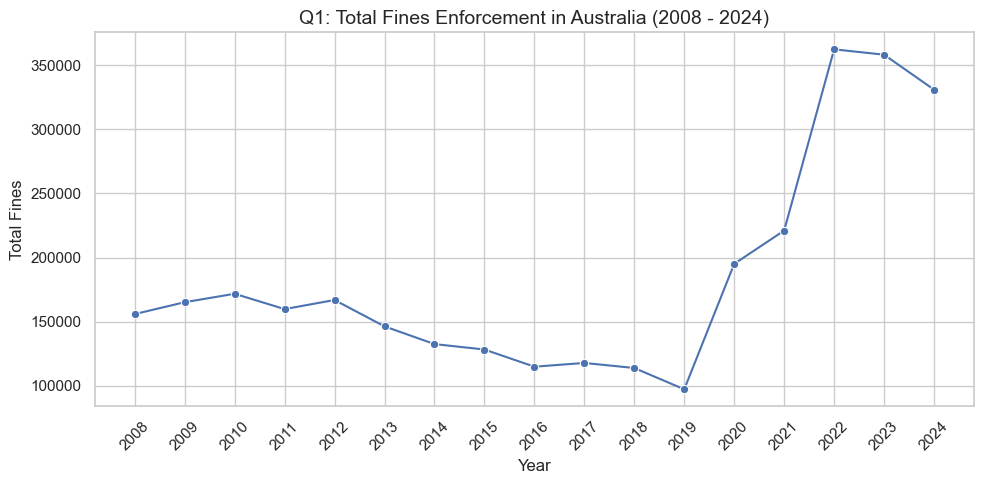

In [40]:
q1_trend = df_mobile.groupby('YEAR')['FINES'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=q1_trend, x='YEAR', y='FINES', marker='o', color='b')
plt.title('Q1: Total Fines Enforcement in Australia (2008 - 2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Fines')
plt.xticks(q1_trend['YEAR'], rotation=45)
plt.tight_layout()
plt.show()

### Question 2: Which jurisdictions consistently record the highest number of mobile phone infringement fines?


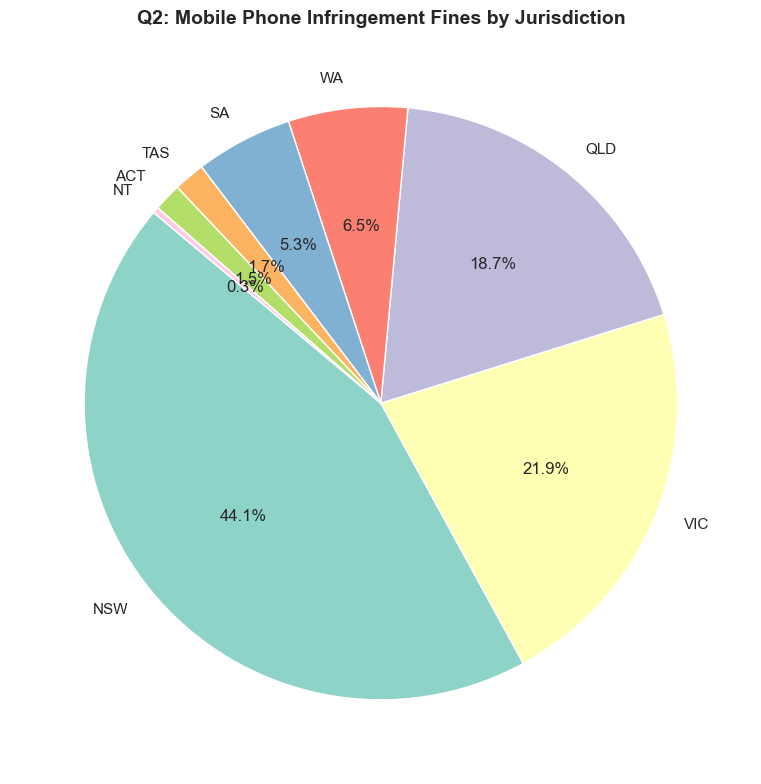

In [41]:
# Group by Jurisdiction and calculate total fines
q2_jurisdiction = df_mobile.groupby('JURISDICTION')['FINES'].sum().reset_index()

# Sort values so the pie chart looks organized
q2_jurisdiction = q2_jurisdiction.sort_values(by='FINES', ascending=False)

# Plotting the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(q2_jurisdiction['FINES'], 
        labels=q2_jurisdiction['JURISDICTION'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set3'))

plt.title('Q2: Mobile Phone Infringement Fines by Jurisdiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Question 3: How do enforcement actions vary across age groups?


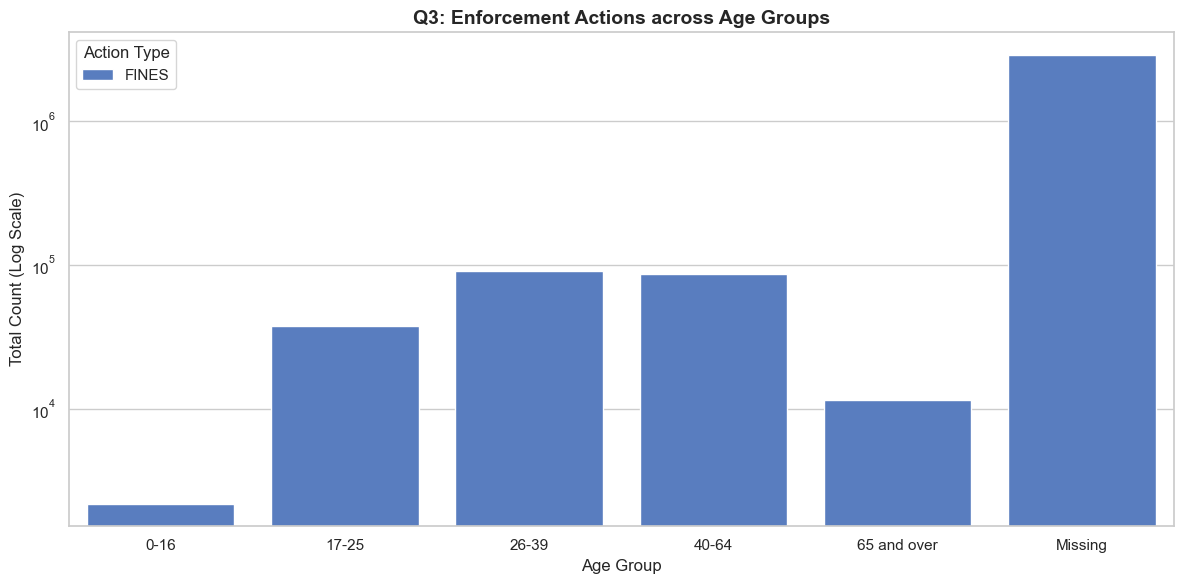

In [42]:
# Group by Age Group
q3_age = df_mobile.groupby('AGE_GROUP')[['FINES']].sum().reset_index()

# Melt the data (Unpivot) for seaborn plotting
q3_melted = q3_age.melt(id_vars='AGE_GROUP', var_name='Enforcement Action', value_name='Total Count')

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q3_melted, x='AGE_GROUP', y='Total Count', hue='Enforcement Action', palette='muted')

plt.title('Q3: Enforcement Actions across Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Using Log Scale because Fines are massively larger than Arrests/Charges
plt.yscale('log') 
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Question 4: What is the composition of enforcement actions?


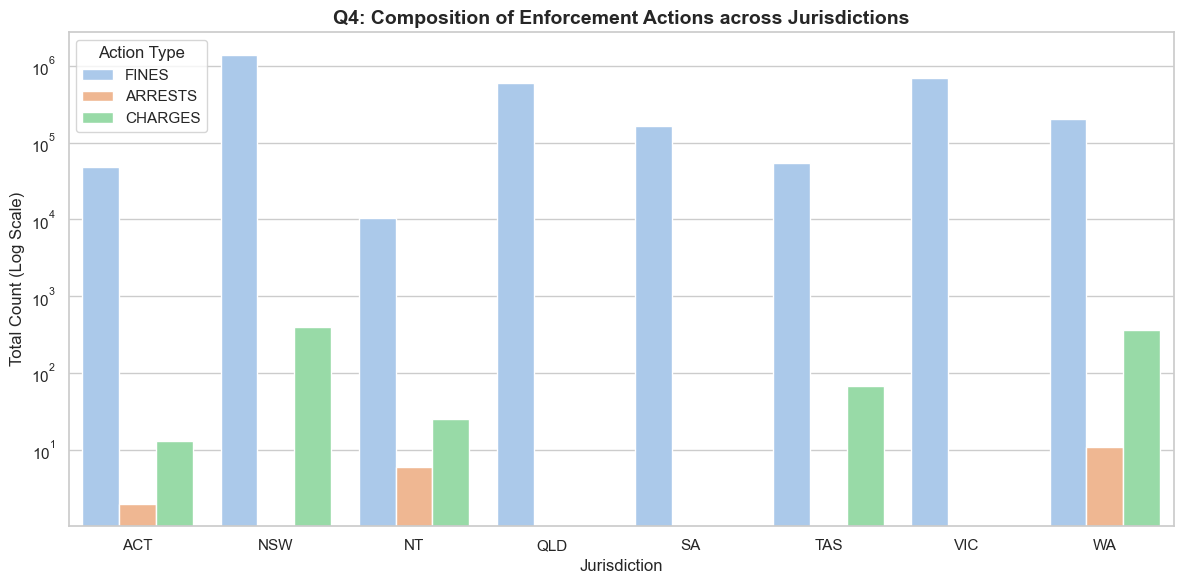

In [43]:
# Group by Jurisdiction and calculate total Fines, Arrests, and Charges
q4_jurisdiction = df_mobile.groupby('JURISDICTION')[['FINES', 'ARRESTS', 'CHARGES']].sum().reset_index()

# Melt the dataframe (Unpivot) to make it suitable for seaborn barplot
q4_melted = q4_jurisdiction.melt(id_vars='JURISDICTION', 
                                 var_name='Action Type', 
                                 value_name='Total Count')

# Plotting the Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q4_melted, x='JURISDICTION', y='Total Count', hue='Action Type', palette='pastel')

# Set English titles and labels
plt.title('Q4: Composition of Enforcement Actions across Jurisdictions', fontsize=14, fontweight='bold')
plt.xlabel('Jurisdiction', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Apply Log Scale because Fines are significantly higher than Arrests and Charges
plt.yscale('log')

# Customize the legend
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Question 5: How does enforcement vary by location type?


/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/100805266.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')


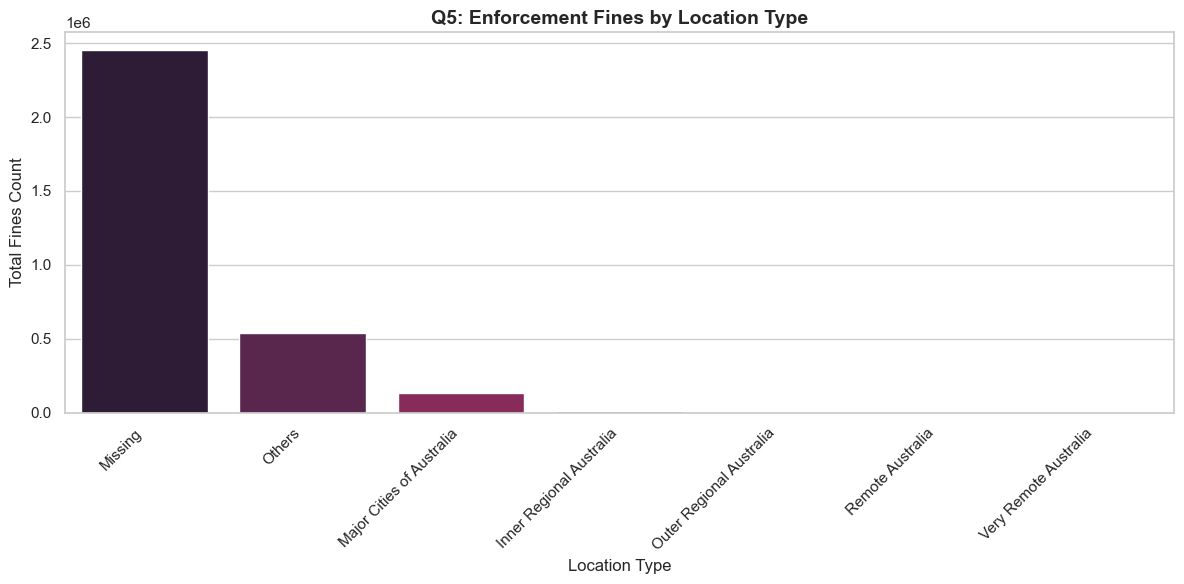

In [44]:
# Group by Location
q5_location = df_mobile.groupby('LOCATION')['FINES'].sum().reset_index()
q5_location = q5_location.sort_values(by='FINES', ascending=False)

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')

plt.title('Q5: Enforcement Fines by Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Total Fines Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate X labels so they don't overlap

plt.tight_layout()
plt.show()

### Q1 (Filtered): How have mobile phone enforcement fines changed across Australia from 2008 to 2024? 


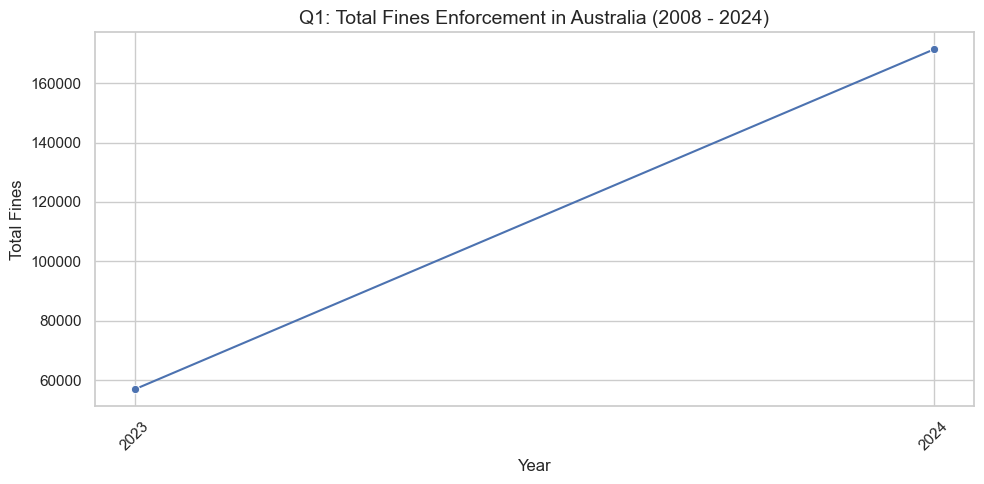

In [45]:
q1_trend = df_final.groupby('YEAR')['FINES'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=q1_trend, x='YEAR', y='FINES', marker='o', color='b')
plt.title('Q1: Total Fines Enforcement in Australia (2008 - 2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Fines')
plt.xticks(q1_trend['YEAR'], rotation=45)
plt.tight_layout()
plt.show()

### Q2 (Filtered): Which jurisdictions consistently record the highest number of mobile phone infringement fines?


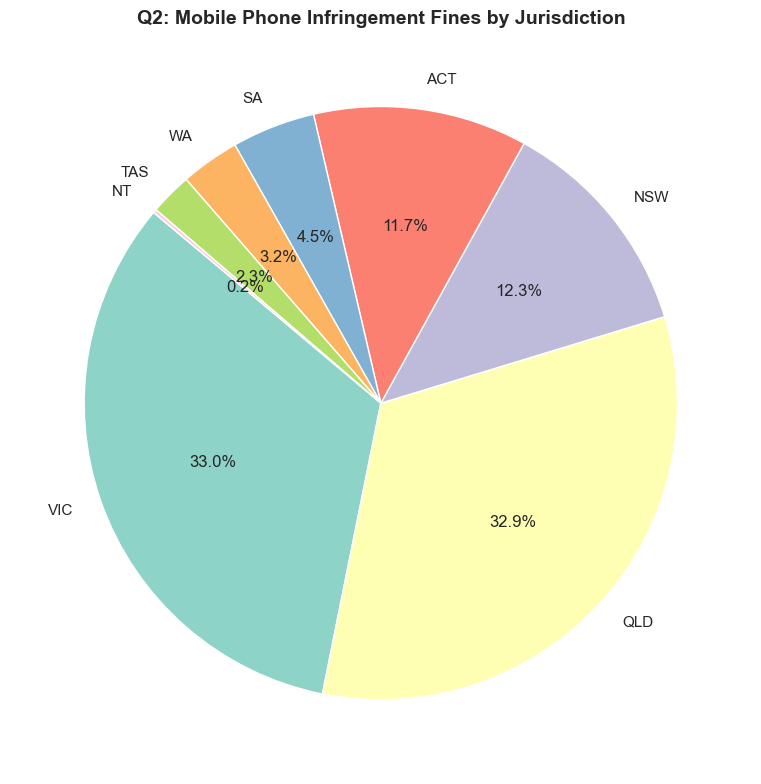

In [46]:
# Group by Jurisdiction and calculate total fines
q2_jurisdiction = df_final.groupby('JURISDICTION')['FINES'].sum().reset_index()

# Sort values so the pie chart looks organized
q2_jurisdiction = q2_jurisdiction.sort_values(by='FINES', ascending=False)

# Plotting the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(q2_jurisdiction['FINES'], 
        labels=q2_jurisdiction['JURISDICTION'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set3'))

plt.title('Q2: Mobile Phone Infringement Fines by Jurisdiction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q3 (Filtered): How do enforcement actions vary across age groups?


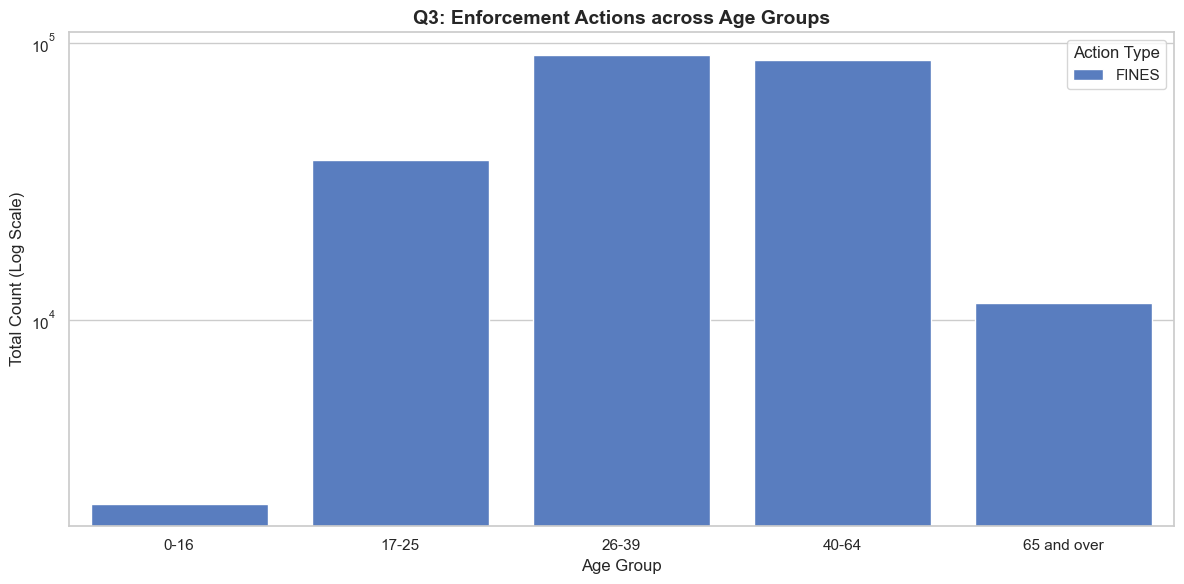

In [47]:
# Group by Age Group
q3_age = df_final.groupby('AGE_GROUP')[['FINES']].sum().reset_index()

# Melt the data (Unpivot) for seaborn plotting
q3_melted = q3_age.melt(id_vars='AGE_GROUP', var_name='Enforcement Action', value_name='Total Count')

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q3_melted, x='AGE_GROUP', y='Total Count', hue='Enforcement Action', palette='muted')

plt.title('Q3: Enforcement Actions across Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Using Log Scale because Fines are massively larger than Arrests/Charges
plt.yscale('log') 
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Q4 (Filtered): What is the composition of enforcement actions?


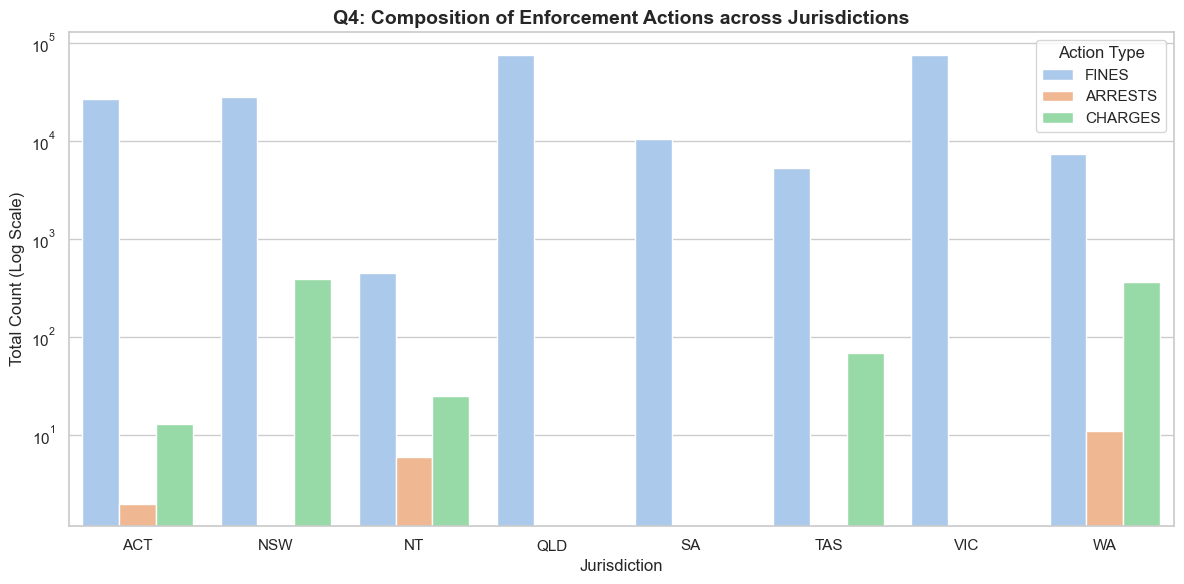

In [ ]:
# Group by Jurisdiction and calculate total Fines, Arrests, and Charges
q4_jurisdiction = df_final.groupby('JURISDICTION')[['FINES', 'ARRESTS', 'CHARGES']].sum().reset_index()

# Melt the dataframe (Unpivot) to make it suitable for seaborn barplot
q4_melted = q4_jurisdiction.melt(id_vars='JURISDICTION', 
                                 var_name='Action Type', 
                                 value_name='Total Count')

# Plotting the Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q4_melted, x='JURISDICTION', y='Total Count', hue='Action Type', palette='pastel')

plt.title('Q4: Composition of Enforcement Actions across Jurisdictions', fontsize=14, fontweight='bold')
plt.xlabel('Jurisdiction', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

# Apply Log Scale because Fines are significantly higher than Arrests and Charges
plt.yscale('log')

# Customize the legend
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()

### Q5 (Filtered): How does enforcement vary by location type?


/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/3426752272.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')


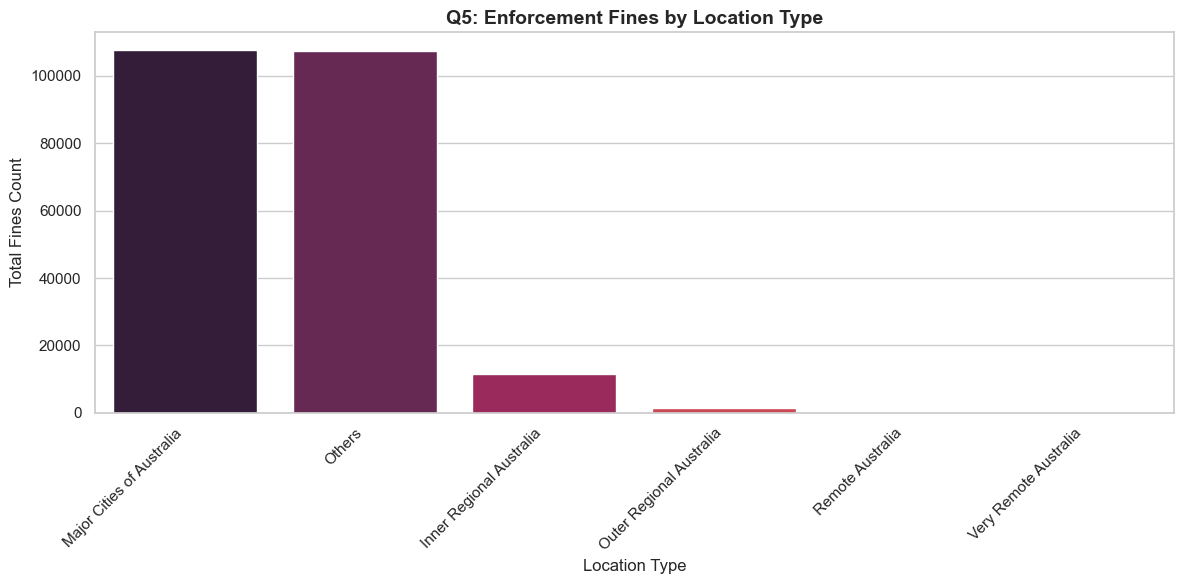

In [49]:
# Group by Location
q5_location = df_final.groupby('LOCATION')['FINES'].sum().reset_index()
q5_location = q5_location.sort_values(by='FINES', ascending=False)

# Plotting the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=q5_location, x='LOCATION', y='FINES', palette='rocket')

plt.title('Q5: Enforcement Fines by Location Type', fontsize=14, fontweight='bold')
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Total Fines Count', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate X labels so they don't overlap

plt.tight_layout()
plt.show()

### Q6 (Filtered): What is the composition of detection methods for mobile phone offences?

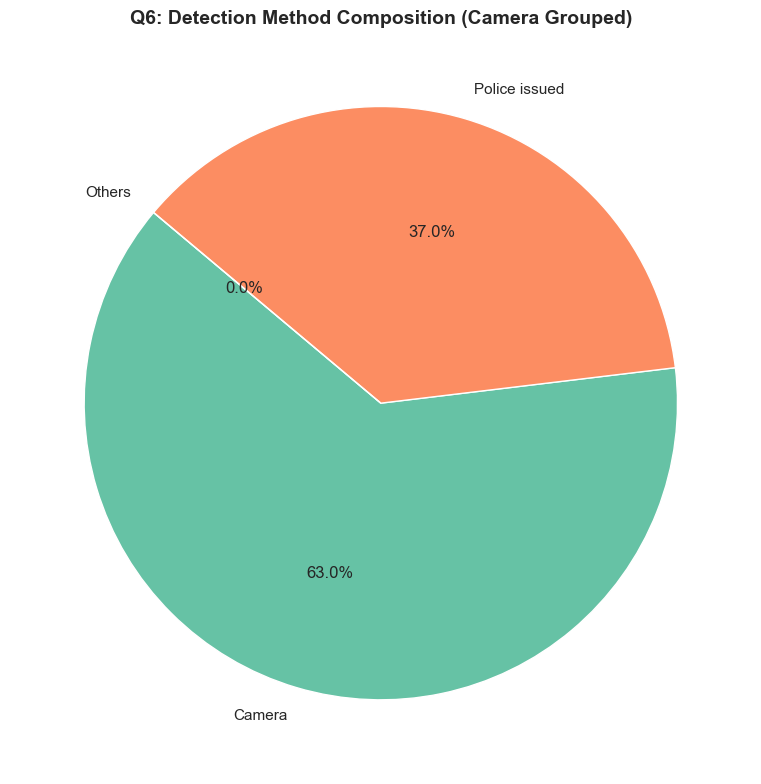

In [50]:
# Group by detection method (filtered dataset) - gộp tất cả loại camera thành 1 nhóm "Camera"
q6_tmp = df_final.copy()

camera_methods = ['Fixed camera', 'Mobile camera', 'Fixed or mobile camera']
q6_tmp['DETECTION_METHOD_GROUPED'] = q6_tmp['DETECTION_METHOD'].replace({m: 'Camera' for m in camera_methods})

q6_detection = q6_tmp.groupby('DETECTION_METHOD_GROUPED', as_index=False)['FINES'].sum()
q6_detection = q6_detection.sort_values('FINES', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    q6_detection['FINES'],
    labels=q6_detection['DETECTION_METHOD_GROUPED'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2')
)

plt.title('Q6: Detection Method Composition (Camera Grouped)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stand Up 2

## Population 

### Load & Process Population Dataset

In [67]:


# Load dataset
pop_file = 'population_state_territory.xlsx'
sheet_name = 'Data1' 
# skiprows=9 to take only total population of each jurisdiction
df_pop_raw = pd.read_excel(pop_file,sheet_name,skiprows=10, header=None)

# Rename column name
target_columns = [0, 18, 19, 20, 21, 22, 23, 24, 25] 
df_pop = df_pop_raw.iloc[:, target_columns].copy()
df_pop.columns = ['DATE', 'NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']

# Convert DATE into datetime và extract YEAR
df_pop['DATE'] = pd.to_datetime(df_pop['DATE'])
df_pop['YEAR'] = df_pop['DATE'].dt.year

# Calculate average number of population by year
df_pop_yearly = df_pop.groupby('YEAR')[['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']].mean().reset_index()

# Convert into int
for col in ['NSW', 'VIC', 'QLD', 'SA', 'WA', 'TAS', 'NT', 'ACT']:
    df_pop_yearly[col] = df_pop_yearly[col].round().astype(int)

# Unpivot column
df_pop_clean = df_pop_yearly.melt(id_vars='YEAR', 
                                  var_name='JURISDICTION', 
                                  value_name='POPULATION')

print(df_pop_clean)


     YEAR JURISDICTION  POPULATION
0    1981          NSW     7507109
1    1982          NSW     7615477
2    1983          NSW     7718404
3    1984          NSW     7813715
4    1985          NSW     7919245
..    ...          ...         ...
347  2020          ACT      247493
348  2021          ACT      248212
349  2022          ACT      250452
350  2023          ACT      253264
351  2024          ACT      255004

[352 rows x 3 columns]


In [52]:
# Build yearly enforcement table
df_state_yearly = df_final.groupby(['YEAR', 'JURISDICTION'])[['FINES', 'ARRESTS', 'CHARGES']].sum().reset_index()

# Standardize merge keys on both sides
for _df in [df_state_yearly, df_pop_clean]:
    _df['YEAR'] = _df['YEAR'].astype(int)
    _df['JURISDICTION'] = _df['JURISDICTION'].astype(str).str.strip().str.upper()

# Optional sanity checks
print('Duplicate keys in df_state_yearly:', df_state_yearly.duplicated(['YEAR', 'JURISDICTION']).sum())
print('Duplicate keys in df_pop_clean   :', df_pop_clean.duplicated(['YEAR', 'JURISDICTION']).sum())

# Check unmatched keys before final merge
merge_check = df_state_yearly.merge(
    df_pop_clean[['YEAR', 'JURISDICTION', 'POPULATION']],
    on=['YEAR', 'JURISDICTION'],
    how='left',
    indicator=True
)
unmatched = merge_check[merge_check['_merge'] != 'both'][['YEAR', 'JURISDICTION']].drop_duplicates()
print(f'Unmatched state-year keys: {len(unmatched)}')
if len(unmatched) > 0:
    display(unmatched.head(20))

# Final merge (strictly one-to-one by key)
df_norm = pd.merge(
    df_state_yearly,
    df_pop_clean[['YEAR', 'JURISDICTION', 'POPULATION']],
    on=['YEAR', 'JURISDICTION'],
    how='inner',
    validate='one_to_one'
)

# Per-capita and per-100k metrics
df_norm['FINES_PER_CAPITA'] = df_norm['FINES'] / df_norm['POPULATION']
df_norm['ARRESTS_PER_CAPITA'] = df_norm['ARRESTS'] / df_norm['POPULATION']
df_norm['CHARGES_PER_CAPITA'] = df_norm['CHARGES'] / df_norm['POPULATION']

df_norm['FINES_PER_100K'] = df_norm['FINES_PER_CAPITA'] * 100000
df_norm['ARRESTS_PER_100K'] = df_norm['ARRESTS_PER_CAPITA'] * 100000
df_norm['CHARGES_PER_100K'] = df_norm['CHARGES_PER_CAPITA'] * 100000

print(f'Final size after merge: {df_norm.shape}')
df_norm[['YEAR', 'JURISDICTION', 'FINES', 'POPULATION', 'FINES_PER_CAPITA', 'FINES_PER_100K']].head()

Duplicate keys in df_state_yearly: 0
Duplicate keys in df_pop_clean   : 0
Unmatched state-year keys: 0
Final size after merge: (15, 12)


,YEAR,JURISDICTION,FINES,POPULATION,FINES_PER_CAPITA,FINES_PER_100K
0,2023,ACT,288,253264,0.001137,113.715333
1,2023,NSW,13285,13460626,0.000987,98.695261
2,2023,NT,205,573960,0.000357,35.716775
3,2023,SA,5769,5477434,0.001053,105.323040
4,2023,TAS,2428,2896072,0.000838,83.837695


### What is the composition of enforcement actions across Jurisdiction after normalization?


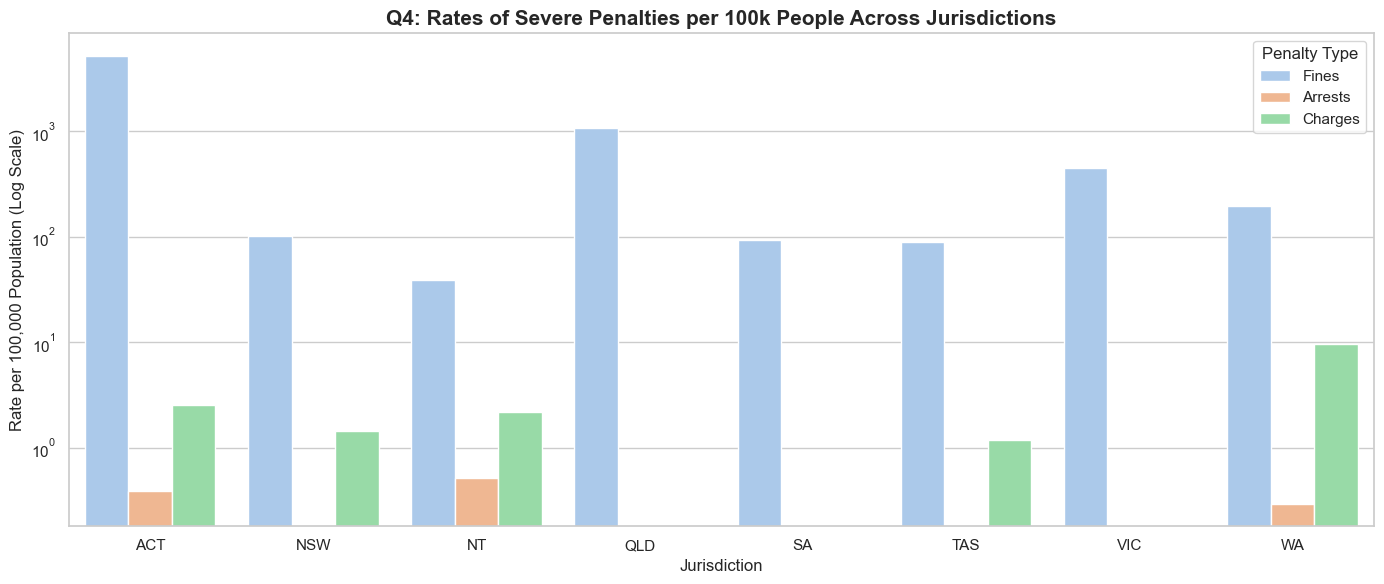

In [53]:
# Prepare data combining per 100k rates
q4_melted = df_norm.groupby('JURISDICTION')[['FINES_PER_100K', 'ARRESTS_PER_100K', 'CHARGES_PER_100K']].mean().reset_index()
q4_melted = q4_melted.melt(id_vars='JURISDICTION', var_name='Penalty Type', value_name='Rate per 100k')

# Clean up the labels for the legend
q4_melted['Penalty Type'] = q4_melted['Penalty Type'].replace({
    'FINES_PER_100K': 'Fines', 
    'ARRESTS_PER_100K': 'Arrests', 
    'CHARGES_PER_100K': 'Charges'
})

plt.figure(figsize=(14, 6))
sns.barplot(data=q4_melted, x='JURISDICTION', y='Rate per 100k', hue='Penalty Type', palette='pastel')

plt.title('Q4: Rates of Severe Penalties per 100k People Across Jurisdictions', fontsize=15, fontweight='bold')
plt.xlabel('Jurisdiction', fontsize=12)
plt.ylabel('Rate per 100,000 Population (Log Scale)', fontsize=12)
plt.yscale('log') # Log scale because Fines deeply outweigh Arrests/Charges
plt.legend(title='Penalty Type')
plt.tight_layout()
plt.show()

### Is there a linear relationship between the rates of fines, arrests, and charges?


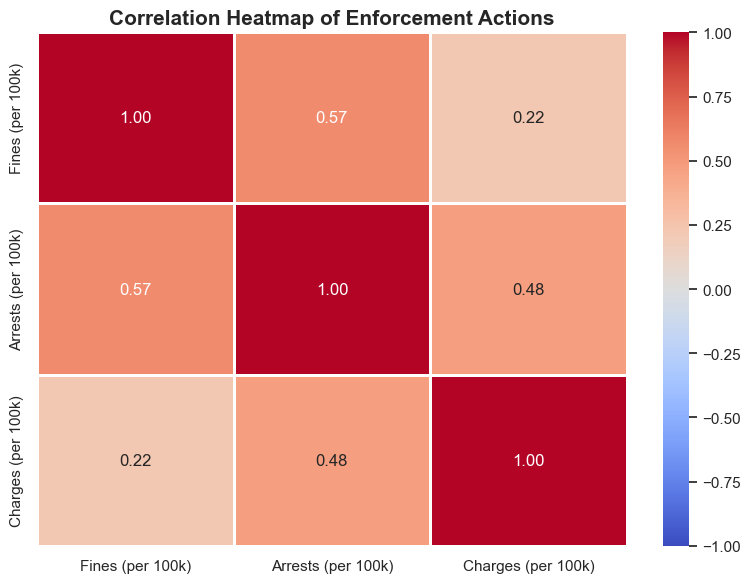

In [54]:
corr_cols = ['FINES_PER_100K', 'ARRESTS_PER_100K', 'CHARGES_PER_100K']
df_corr = df_norm[corr_cols].copy()

df_corr.columns = ['Fines (per 100k)', 'Arrests (per 100k)', 'Charges (per 100k)']

correlation_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=1, linecolor='white', vmin=-1, vmax=1)

plt.title('Correlation Heatmap of Enforcement Actions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Which jurisdictions have the highest violation rates per 100k, and how different are rankings compared with absolute counts?


/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/791813556.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q1_abs, x='FINES', y='JURISDICTION', palette='Blues_r', ax=axes[0])
/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/791813556.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q1_rate, x='FINES_PER_100K', y='JURISDICTION', palette='Reds_r', ax=axes[1])


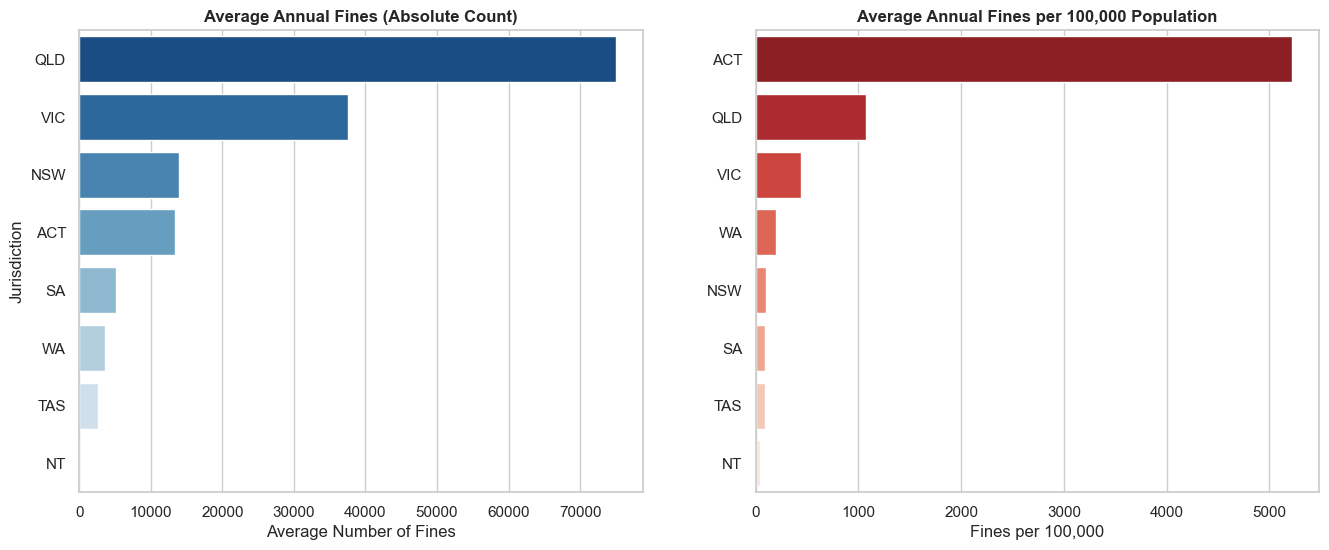

In [55]:
#compare absolute fines vs population-normalized rates
q1_abs = df_norm.groupby('JURISDICTION', as_index=False)['FINES'].mean().sort_values('FINES', ascending=False)
q1_rate = df_norm.groupby('JURISDICTION', as_index=False)['FINES_PER_100K'].mean().sort_values('FINES_PER_100K', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=q1_abs, x='FINES', y='JURISDICTION', palette='Blues_r', ax=axes[0])
axes[0].set_title('Average Annual Fines (Absolute Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Number of Fines')
axes[0].set_ylabel('Jurisdiction')

sns.barplot(data=q1_rate, x='FINES_PER_100K', y='JURISDICTION', palette='Reds_r', ax=axes[1])
axes[1].set_title('Average Annual Fines per 100,000 Population', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fines per 100,000')
axes[1].set_ylabel('')


plt.show()

In [56]:
# Export merged dataset (df_norm) to CSV and Excel
import os

output_dir = 'exports'
os.makedirs(output_dir, exist_ok=True)


xlsx_path = os.path.join(output_dir, 'mobile_phone_enforcement_merged.xlsx')

df_norm.to_excel(xlsx_path, index=False)

print('Export completed successfully')
print(f'XLSX: {xlsx_path}')
print(f'Rows: {len(df_norm)}, Columns: {df_norm.shape[1]}')

Export completed successfully
XLSX: exports/mobile_phone_enforcement_merged.xlsx
Rows: 15, Columns: 12


## Age Group

In [77]:
import re

state_files = {
    'NSW': 'nsw.xlsx',
    'VIC': 'victoria.xlsx',
    'QLD': 'queensland.xlsx',
    'SA': 'south_aus.xlsx',
    'WA': 'western_aus.xlsx',
    'TAS': 'tasmania.xlsx',
    'NT': 'northern_territory.xlsx',
    'ACT': 'aus_capital_territory.xlsx'
}

age_bins = ['0-16', '17-25', '26-39', '40-64', '65 and over']
all_states_pop_long = []

for state_code, filename in state_files.items():
    data1 = pd.read_excel(filename, sheet_name='Data1')
    data2 = pd.read_excel(filename, sheet_name='Data2')
    data1 = data1.rename(columns={data1.columns[0]: 'DATE'})
    data2 = data2.rename(columns={data2.columns[0]: 'DATE'})
    pop_raw = pd.merge(data1, data2, on='DATE', how='inner')
    pop_raw['DATE'] = pd.to_datetime(pop_raw['DATE'], errors='coerce')
    pop_raw = pop_raw.dropna(subset=['DATE'])
    pop_raw['YEAR'] = pop_raw['DATE'].dt.year
    person_cols = [c for c in pop_raw.columns if 'Persons' in str(c)]
    for b in age_bins:
        pop_raw[b] = 0
    for col in person_cols:
        col_name = str(col)
        match = re.search(r'(\d+)', col_name)
        if not match:
            continue
        age = int(match.group(1))
        if 0 <= age <= 16:
            pop_raw['0-16'] += pop_raw[col]
        elif 17 <= age <= 25:
            pop_raw['17-25'] += pop_raw[col]
        elif 26 <= age <= 39:
            pop_raw['26-39'] += pop_raw[col]
        elif 40 <= age <= 64:
            pop_raw['40-64'] += pop_raw[col]
        elif age >= 65:
            pop_raw['65 and over'] += pop_raw[col]
    pop_yearly = pop_raw.groupby('YEAR')[age_bins].mean().reset_index()
    pop_long = pop_yearly.melt(id_vars='YEAR', var_name='AGE_GROUP', value_name='POPULATION')
    pop_long['JURISDICTION'] = state_code
    all_states_pop_long.append(pop_long)

pop_age_all_states = pd.concat(all_states_pop_long, ignore_index=True)
pop_age_all_states['YEAR'] = pop_age_all_states['YEAR'].astype(int)
pop_age_all_states['JURISDICTION'] = pop_age_all_states['JURISDICTION'].astype(str).str.strip().str.upper()
pop_age_all_states['AGE_GROUP'] = pop_age_all_states['AGE_GROUP'].astype(str).str.strip()

# Prepare enforcement data with quarterly breakdown
df_age_base = df_final.copy()
camera_methods = ['Fixed camera', 'Mobile camera', 'Fixed or mobile camera']
df_age_base['DETECTION_METHOD'] = df_age_base['DETECTION_METHOD'].replace({m: 'Camera' for m in camera_methods})

location_map = {
    'Major Cities of Australia': 'Urban',
    'Inner Regional Australia': 'Regional',
    'Outer Regional Australia': 'Regional',
    'Remote Australia': 'Regional',
    'Very Remote Australia': 'Regional',
    'Others': 'Others'
}
df_age_base['LOCATION'] = df_age_base['LOCATION'].replace(location_map)

# Extract Quarter from END_DATE
df_age_base['QUARTER'] = df_age_base['END_DATE'].dt.quarter
df_age_base['YEAR_QUARTER'] = df_age_base['YEAR'].astype(str) + '-Q' + df_age_base['QUARTER'].astype(str)

# Group by quarterly dimensions
df_age_quarterly_all = (
    df_age_base.groupby(['YEAR', 'QUARTER', 'YEAR_QUARTER', 'JURISDICTION', 'AGE_GROUP', 'LOCATION', 'DETECTION_METHOD'])[['FINES', 'ARRESTS', 'CHARGES']]
    .sum()
    .reset_index()
)

df_age_quarterly_all['YEAR'] = df_age_quarterly_all['YEAR'].astype(int)
df_age_quarterly_all['QUARTER'] = df_age_quarterly_all['QUARTER'].astype(int)
df_age_quarterly_all['JURISDICTION'] = df_age_quarterly_all['JURISDICTION'].astype(str).str.strip().str.upper()
df_age_quarterly_all['AGE_GROUP'] = df_age_quarterly_all['AGE_GROUP'].astype(str).str.strip()
df_age_quarterly_all['LOCATION'] = df_age_quarterly_all['LOCATION'].astype(str).str.strip()
df_age_quarterly_all['DETECTION_METHOD'] = df_age_quarterly_all['DETECTION_METHOD'].astype(str).str.strip()
df_age_quarterly_all['YEAR_QUARTER'] = df_age_quarterly_all['YEAR_QUARTER'].astype(str).str.strip()

# Merge with yearly population (using yearly population across all quarters)
df_age_norm_all = pd.merge(
    df_age_quarterly_all,
    pop_age_all_states[['YEAR', 'JURISDICTION', 'AGE_GROUP', 'POPULATION']],
    on=['YEAR', 'JURISDICTION', 'AGE_GROUP'],
    how='inner',
    validate='many_to_one'
)

# Calculate per-100k metrics
df_age_norm_all['FINES_PER_100K'] = (df_age_norm_all['FINES'] / df_age_norm_all['POPULATION']) * 100000
df_age_norm_all['ARRESTS_PER_100K'] = (df_age_norm_all['ARRESTS'] / df_age_norm_all['POPULATION']) * 100000
df_age_norm_all['CHARGES_PER_100K'] = (df_age_norm_all['CHARGES'] / df_age_norm_all['POPULATION']) * 100000

print('Loaded files:', list(state_files.values()))
print('Population table shape:', pop_age_all_states.shape)
print('Enforcement table shape (quarterly):', df_age_quarterly_all.shape)
print('Merged table shape (quarterly):', df_age_norm_all.shape)
print('\nRetained columns:', ['YEAR', 'QUARTER', 'YEAR_QUARTER', 'JURISDICTION', 'AGE_GROUP', 'LOCATION', 'DETECTION_METHOD'])
print('Quarters covered:', sorted(df_age_norm_all['YEAR_QUARTER'].unique().tolist()))
print('Location categories:', sorted(df_age_norm_all['LOCATION'].unique().tolist()))
print('Detection methods:', sorted(df_age_norm_all['DETECTION_METHOD'].unique().tolist()))
print('\nSample (first 10 rows):')
print(df_age_norm_all[['YEAR', 'QUARTER', 'YEAR_QUARTER', 'JURISDICTION', 'AGE_GROUP', 'LOCATION', 'DETECTION_METHOD', 'FINES', 'FINES_PER_100K']].head(10))

/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/474741098.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pop_raw['DATE'] = pd.to_datetime(pop_raw['DATE'], errors='coerce')
/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/474741098.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pop_raw['DATE'] = pd.to_datetime(pop_raw['DATE'], errors='coerce')
/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/474741098.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pop_raw['DATE'] = pd.to_datetime(pop_raw['DATE'], errors='coer

Loaded files: ['nsw.xlsx', 'victoria.xlsx', 'queensland.xlsx', 'south_aus.xlsx', 'western_aus.xlsx', 'tasmania.xlsx', 'northern_territory.xlsx', 'aus_capital_territory.xlsx']
Population table shape: (2160, 4)
Enforcement table shape (quarterly): (557, 10)
Merged table shape (quarterly): (557, 14)

Retained columns: ['YEAR', 'QUARTER', 'YEAR_QUARTER', 'JURISDICTION', 'AGE_GROUP', 'LOCATION', 'DETECTION_METHOD']
Quarters covered: ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']
Location categories: ['Others', 'Regional', 'Urban']
Detection methods: ['Camera', 'Others', 'Police issued']

Sample (first 10 rows):
   YEAR  QUARTER YEAR_QUARTER JURISDICTION    AGE_GROUP  LOCATION  \
0  2023        1      2023-Q1          ACT         0-16     Urban   
1  2023        1      2023-Q1          ACT        17-25     Urban   
2  2023        1      2023-Q1          ACT        26-39     Urban   
3  2023        1      2023-Q1          ACT        40-64     Urban   

/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/474741098.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pop_raw['DATE'] = pd.to_datetime(pop_raw['DATE'], errors='coerce')


/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/422829136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


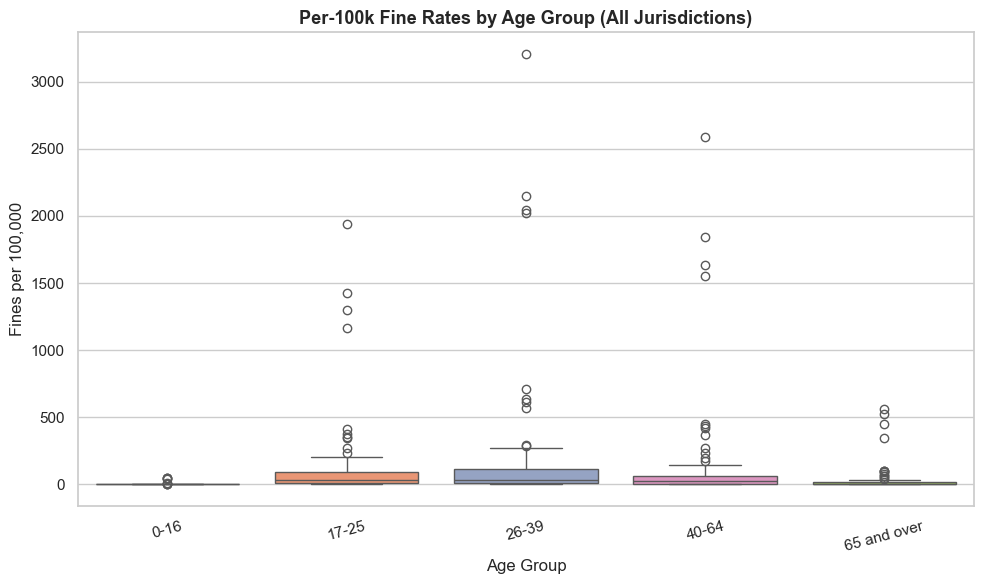

In [78]:
# Box plot: Per-100k Fine Rates by Age Group (All Jurisdictions)
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_age_norm_all,
    x='AGE_GROUP',
    y='FINES_PER_100K',
    order=['0-16', '17-25', '26-39', '40-64', '65 and over'],
    palette='Set2'
)
plt.title('Per-100k Fine Rates by Age Group (All Jurisdictions)', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Fines per 100,000')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

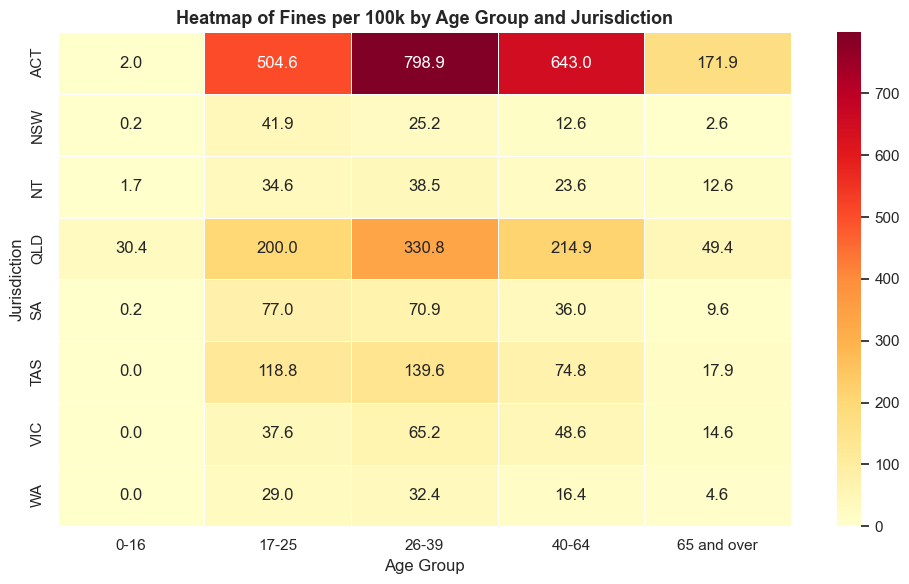

In [79]:
# Heatmap: FINES_PER_100K by Age Group across Jurisdictions
heat_age_jur = (
    df_age_norm_all
    .groupby(['JURISDICTION', 'AGE_GROUP'], as_index=False)['FINES_PER_100K']
    .mean()
    .pivot(index='JURISDICTION', columns='AGE_GROUP', values='FINES_PER_100K')
)

# keep consistent age order
heat_age_jur = heat_age_jur.reindex(columns=['0-16', '17-25', '26-39', '40-64', '65 and over'])
heat_age_jur = heat_age_jur.apply(pd.to_numeric, errors='coerce').astype(float)

plt.figure(figsize=(10, 6))
sns.heatmap(heat_age_jur, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=.5)
plt.title('Heatmap of Fines per 100k by Age Group and Jurisdiction', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Jurisdiction')
plt.tight_layout()
plt.show()

/var/folders/qz/7ggctf4n0bs4_nw3nw7x23qr0000gn/T/ipykernel_54222/4032914696.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


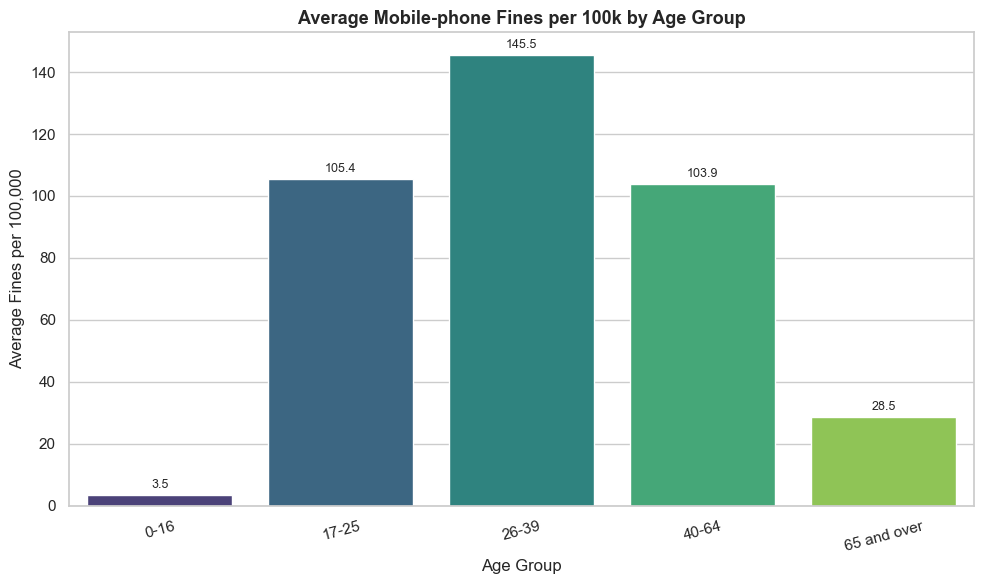

In [83]:
age_order = ['0-16', '17-25', '26-39', '40-64', '65 and over']

q_age_bar = (
    df_age_norm_all.groupby('AGE_GROUP', as_index=False)['FINES_PER_100K']
    .mean()
)
q_age_bar['AGE_GROUP'] = pd.Categorical(q_age_bar['AGE_GROUP'], categories=age_order, ordered=True)
q_age_bar = q_age_bar.sort_values('AGE_GROUP')

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=q_age_bar,
    x='AGE_GROUP',
    y='FINES_PER_100K',
    palette='viridis'
)

plt.title('Average Mobile-phone Fines per 100k by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Fines per 100,000')
plt.xticks(rotation=15)

# optional: show value labels
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

In [82]:
# Export quarterly age-group merged dataset (all states)
import os

output_dir = 'exports'
os.makedirs(output_dir, exist_ok=True)

age_xlsx_path = os.path.join(output_dir, 'mobile_phone_enforcement_age_all_states.xlsx')
df_age_norm_all.to_excel(age_xlsx_path, index=False)

print('Export completed successfully')
print(f'XLSX: {age_xlsx_path}')
print(f'Rows: {len(df_age_norm_all)}, Columns: {df_age_norm_all.shape[1]}')
print(f'Quarters: {sorted(df_age_norm_all["YEAR_QUARTER"].unique().tolist())}')

Export completed successfully
XLSX: exports/mobile_phone_enforcement_age_all_states.xlsx
Rows: 557, Columns: 14
Quarters: ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']
